In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import NC16Model, NC16MagFilter, Obs, Univariate, ObsVecNoise

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

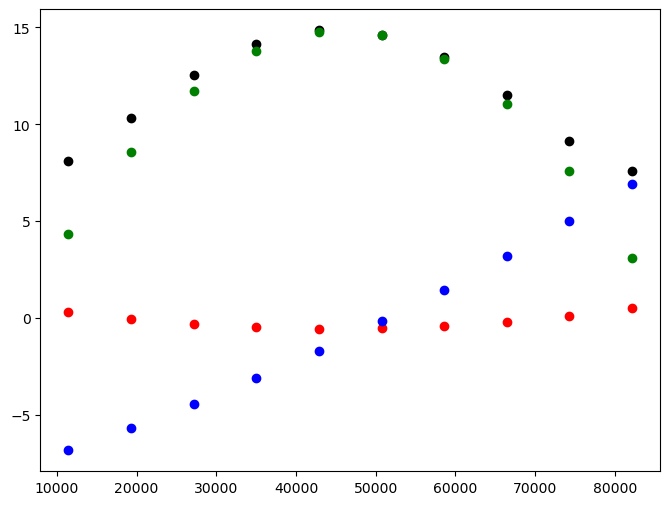

In [2]:
# Set up model priors
model = NC16Model([
    Univariate.uniform("phi", 0.5 * np.pi, 2.5 * np.pi),
    Univariate.uniform("theta", - np.pi / 2, np.pi / 2),
    Univariate.uniform("y_0", -0.95, 0.95),
    Univariate.uniform("radius", 0.025, 0.2),
    Univariate.uniform("x_0", 0.5, 1.0),
    Univariate.constant("speed", 500),
    Univariate.uniform("b_star", 10, 25),
    Univariate.uniform("tau", 1, 2),
    Univariate.uniform("c10", -15.0, 15.0),
])

params = np.array([[
    np.deg2rad(365), 
    np.deg2rad(-5), 
    0.1, 
    0.13, 
    0.85,
    500,
    15,
    1.1,
    2
]])

T = 24
K = 12
N = 2048
S = 1

obs = Obs(
    [3600 + i * 3600 * (T / (K - 1)) for i in range(K)],
    np.array([[1.0, 0.0, 0.0] for _ in range(K)])
)

covmat = S * np.eye(obs.count())

# assert that all points are within the fr (and not NaN)
diag = model.icsbasis(obs, params)
assert np.all(diag.get(0)[0][1:-1, 0] < 1.0)

output = model.simulate_mag(obs, params).get(0)

plt.figure(figsize=(8, 6))
plt.scatter(obs.timestamps(), np.sqrt(np.sum(output**2, axis=1)), color="k")
plt.scatter(obs.timestamps(), output[:, 0], color="r")
plt.scatter(obs.timestamps(), output[:, 1], color="g")
plt.scatter(obs.timestamps(), output[:, 2], color="b")
plt.show()

In [3]:
filter = model.new_mag_filter(obs, output, 2048, 42, simulation_time_limit=20)
filter.initialize(metric='nrmse', threshold=0.9)

particles_init = filter.particles()

In [ ]:
filter_abc = filter.copy()

noise = ObsVecNoise.additive_normal(std_dev=np.sqrt(S))

for threshold in [0.7, 0.6, 0.5, 0.4, 0.3, 0.25, 0.2, 0.15]:
    ess = filter_abc.abc_mvnk(metric='nrmse', threshold=threshold, noise=noise)
    print("Filtering with threshold {}, effective sample size: {:.1f}".format(threshold, ess))

print("ABC Mean: {:.3f}".format(np.mean(filter_abc.errors())))
print("ABC Minimum: {:.3f}".format(np.min(filter_abc.errors())))

particles_abc = filter_abc.particles()
abc_min = filter_abc.particles()[0][np.argmin(filter_abc.errors())]

Filtering with threshold 0.7, effective sample size: 769.8
Filtering with threshold 0.6, effective sample size: 1534.3
Filtering with threshold 0.5, effective sample size: 1343.6
Filtering with threshold 0.4, effective sample size: 796.7
Filtering with threshold 0.3, effective sample size: 1570.5
Filtering with threshold 0.25, effective sample size: 1652.5
Filtering with threshold 0.2, effective sample size: 1531.5
Filtering with threshold 0.15, effective sample size: 1679.5
ABC Mean: 0.110
ABC Minimum: 0.024


In [5]:
obs_sir = obs.subset(list(range(1, obs.count()-1)))

filter_sir = model.new_mag_filter_with_particles(obs_sir, output[1:-1], filter_abc.particles()[0], 42, simulation_time_limit=10)

for i in [5, 4, 3, 2, 1.5, 1, 1, 1]:
    (ess, us) = filter_sir.sir_mvnk(i * S * np.eye(obs_sir.count()))
    print("SIR Filtering with covariance scale {}, effective sample size: {:.1f}, unique samples {}".format(i, ess, us))

particles_sir = filter_sir.particles()
sir_max = filter_sir.particles()[0][np.argmax(filter_sir.errors())]

SIR Filtering with covariance scale 5, effective sample size: 144.0, unique samples 1117
SIR Filtering with covariance scale 4, effective sample size: 364.4, unique samples 740
SIR Filtering with covariance scale 3, effective sample size: 595.7, unique samples 951
SIR Filtering with covariance scale 2, effective sample size: 473.6, unique samples 857
SIR Filtering with covariance scale 1.5, effective sample size: 897.4, unique samples 1065
SIR Filtering with covariance scale 1, effective sample size: 508.6, unique samples 910
SIR Filtering with covariance scale 1, effective sample size: 2376.1, unique samples 1458
SIR Filtering with covariance scale 1, effective sample size: 2117.9, unique samples 1421


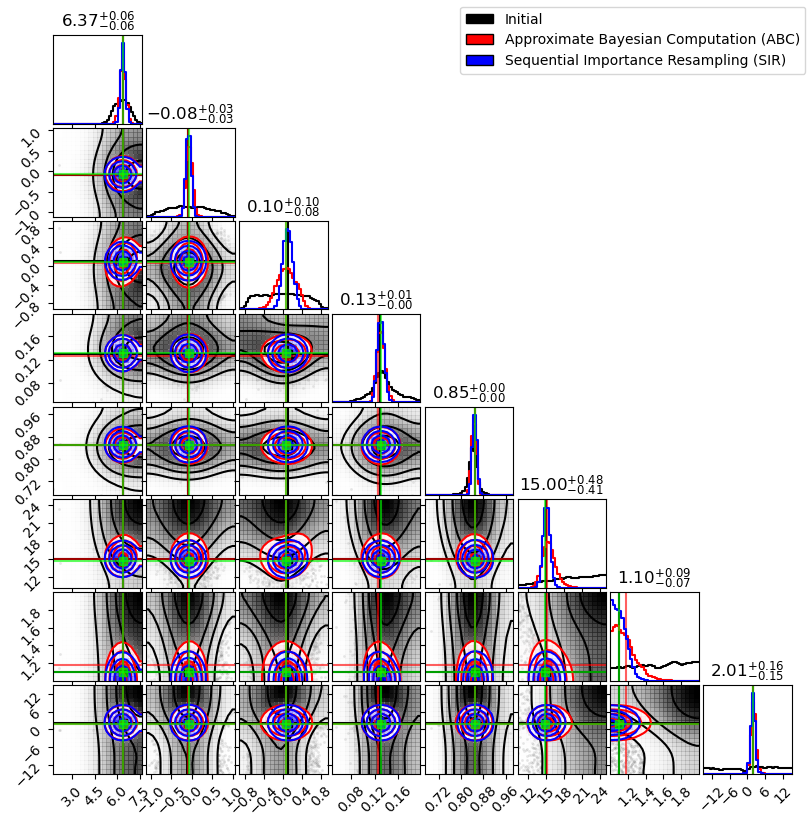

In [6]:
autorange = np.array([np.min(particles_init[0], axis=0), np.max(particles_init[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_init[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / N, color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=params[0][autoflag], truth_color='k')
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=abc_min[autoflag], truth_color='#ff0000a0')
corner.corner(particles_sir[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / N, color='b',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=sir_max[autoflag], truth_color='#00ff00a0', show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='b', edgecolor='k', label="Sequential Importance Resampling (SIR)"),
], loc='upper right')
plt.show()